In [38]:
# Exploring Contextual Language Understanding using BERT

## Objective
#This project explores the capabilities of transformer-based language models using BERT for sentiment analysis and contextual understanding.

#The project demonstrates:
#- Natural Language Processing (NLP)
#- Transformer-based Language Models
#- Sentiment Analysis
#- Contextual Understanding
#- Visualization and Analysis of LM Responses

#The implementation uses pretrained models from Hugging Face Transformers.

In [20]:
!pip install transformers

In [21]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
## Libraries Used

#- Transformers → For pretrained BERT models
#- Pandas → Data handling and analysis
#- Matplotlib → Visualization
#- Seaborn → Statistical plotting

In [23]:
classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [24]:
result = classifier(
    "I absolutely love working on AI projects!"
)

print(result)

[{'label': 'POSITIVE', 'score': 0.9996894598007202}]


In [25]:
texts = [
    "I absolutely loved this movie!",
    "The service was terrible.",
    "The product quality is excellent.",
    "I am disappointed with the results.",
    "The experience was average."
]

results = classifier(texts)

results

[{'label': 'POSITIVE', 'score': 0.9998785257339478},
 {'label': 'NEGATIVE', 'score': 0.9996507167816162},
 {'label': 'POSITIVE', 'score': 0.9998691082000732},
 {'label': 'NEGATIVE', 'score': 0.9997925162315369},
 {'label': 'NEGATIVE', 'score': 0.9259572625160217}]

In [26]:
import pandas as pd

df = pd.DataFrame({
    'Text': texts,
    'Sentiment': [r['label'] for r in results],
    'Confidence': [r['score'] for r in results]
})

df

,Text,Sentiment,Confidence
0,I absolutely loved this movie!,POSITIVE,0.999879
1,The service was terrible.,NEGATIVE,0.999651
2,The product quality is excellent.,POSITIVE,0.999869
3,I am disappointed with the results.,NEGATIVE,0.999793
4,The experience was average.,NEGATIVE,0.925957


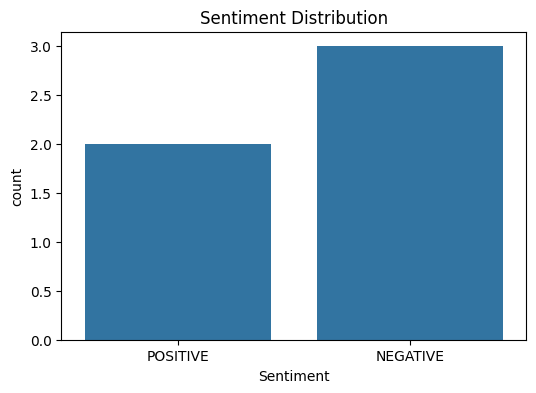

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

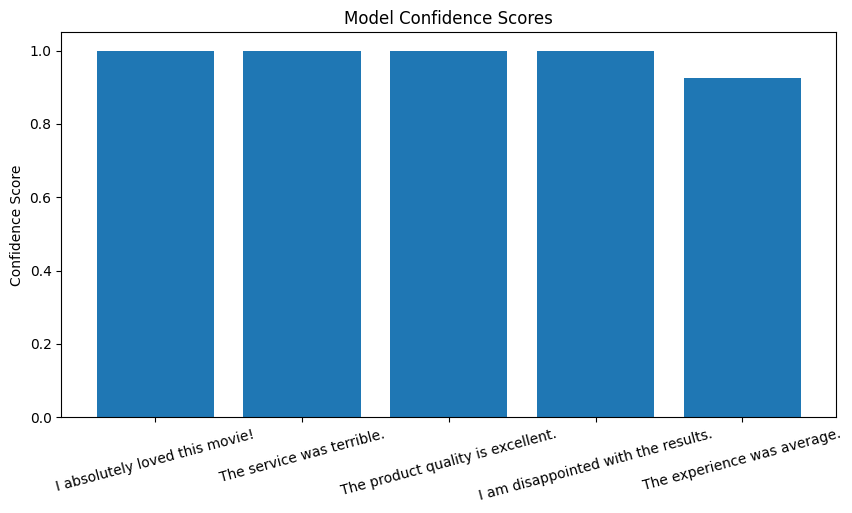

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    df['Text'],
    df['Confidence']
)

plt.xticks(rotation=15)

plt.ylabel("Confidence Score")

plt.title("Model Confidence Scores")

plt.show()

In [29]:
advanced_texts = [
    "The movie started slowly but became fantastic later.",
    "I expected better performance from the product.",
    "The experience was not bad at all.",
    "Although expensive, the phone is worth it.",
    "The support team tried hard but the issue remained unresolved."
]

advanced_results = classifier(advanced_texts)

advanced_df = pd.DataFrame({
    'Text': advanced_texts,
    'Sentiment': [r['label'] for r in advanced_results],
    'Confidence': [r['score'] for r in advanced_results]
})

advanced_df

,Text,Sentiment,Confidence
0,The movie started slowly but became fantastic ...,POSITIVE,0.995098
1,I expected better performance from the product.,NEGATIVE,0.997934
2,The experience was not bad at all.,POSITIVE,0.997695
3,"Although expensive, the phone is worth it.",POSITIVE,0.999859
4,The support team tried hard but the issue rema...,NEGATIVE,0.997835


In [30]:
import re

def preprocess_text(text):

    # convert to lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [31]:
#text preprocessing
sample = "WOW!!! This product is AMAZING!!!"

cleaned = preprocess_text(sample)

print(cleaned)

wow this product is amazing


In [32]:
from transformers import AutoTokenizer

In [33]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

In [34]:
tokens = tokenizer.tokenize(
    "Transformers are revolutionizing NLP."
)

print(tokens)

['transformers', 'are', 'revolution', '##izing', 'nl', '##p', '.']


In [35]:
#learnings-:

## Tokenization

#Tokenization converts text into smaller units called tokens.

#Transformer models process tokens rather than raw text.

#Subword tokenization helps BERT:
#- handle unknown words
#- reduce vocabulary size
#- improve contextual understanding

In [36]:
## Transfer Learning

#The pretrained BERT model was originally trained on massive text corpora.

#Instead of training from scratch, pretrained weights are reused for downstream NLP tasks such as sentiment analysis.

#This significantly reduces training cost and improves performance.

In [37]:
# Conclusion and Output Analysis

#The transformer-based BERT model demonstrated strong contextual language understanding capabilities during sentiment analysis.
#The model successfully interpreted nuanced and mixed-emotion sentences rather than relying solely on individual keywords.

#Key observations from the outputs include:

# - The sentence *“The experience was not bad at all”* was correctly classified as POSITIVE despite containing the word “bad,” showing that the model understands contextual semantics and negation handling.

# - Sentences containing mixed sentiment, such as *“The movie started slowly but became fantastic later”*, were interpreted based on the overall contextual meaning instead of isolated phrases.

# - The model generated very high confidence scores (above 99% in most cases), indicating strong prediction certainty for sentiment classification tasks.

# - Negative sentiment was accurately detected in statements expressing dissatisfaction or unresolved issues, such as *“I expected better performance from the product”* and *“The support team tried hard but the issue remained unresolved.”*

# Overall, the project demonstrates that transformer-based Language Models like BERT are highly effective for Natural Language Processing tasks involving sentiment analysis and contextual interpretation.
# The model performs significantly better than traditional keyword-based approaches because it captures semantic relationships and contextual dependencies between words.

#The project also provided practical understanding of:

# - Transformer architecture
# - Tokenization
# - Contextual embeddings
# - NLP inference pipelines
# - Sentiment classification workflows
# - Visualization and evaluation techniques

#However, the analysis also highlights certain limitations of pretrained language models, including potential difficulty with sarcasm, ambiguity, and highly domain-specific language.
